# Histogram task tied exp

In [24]:
import pandas as pd
import pickle
import numpy as np
import matplotlib.pyplot as plt
import torch
import glob
import os

# run_id = "20251117_0801"  # rho = 2, d = 100, seq_len = 30
# run_id = "20251117_0814" # rho = 1, d = 100, seq_len = 30
# run_id = "20251117_0845" # rho = 1, d = 100, seq_len = 15
# run_id = "20251117_0906" # rho = 0.75, d = 100, seq_len = 30
# run_id = "20251117_0942" # rho = 0.75, d = 100, seq_len = 30

# run_id = "20251124_1422" # MLP 
run_id = "20251124_1646" # MLP 

In [25]:
run_dir = f"../results/run_{run_id}/"
config_path = f"../results/run_{run_id}/config.csv"
base_path = f"../results/run_{run_id}/summary.csv"

## 1. experiment config

In [26]:
# --- Read the CSV file ---
config = pd.read_csv(config_path)
print(f"⚙️ Config loaded ({len(config)} rows) from {config_path}")

# --- Quick preview ---
display(config)

⚙️ Config loaded (10 rows) from ../results/run_20251124_1646/config.csv


,D,L,T,MLP_dim,alpha,rho,beta,lam_list,samples,max_iter,...,N_valid,device,logger,run_dir,run_index,seed,batch_size,R,N_train,N_total
0,100,10,15,15,0.050000,1.0,1.0,[0.0001],1,5000,...,2000,cuda,<Logger logger_0_2733970 (DEBUG)>,/home/peucelle/tpiv-simulations/results/run_20...,0,42,64,100,500,4500
1,100,10,15,15,0.683333,1.0,1.0,[0.0001],1,5000,...,2000,cuda,<Logger logger_6_2733976 (DEBUG)>,/home/peucelle/tpiv-simulations/results/run_20...,6,42,64,100,6833,10833
2,100,10,15,15,0.155556,1.0,1.0,[0.0001],1,5000,...,2000,cuda,<Logger logger_1_2733971 (DEBUG)>,/home/peucelle/tpiv-simulations/results/run_20...,1,42,64,100,1555,5555
3,100,10,15,15,0.261111,1.0,1.0,[0.0001],1,5000,...,2000,cuda,<Logger logger_2_2733972 (DEBUG)>,/home/peucelle/tpiv-simulations/results/run_20...,2,42,64,100,2611,6611
4,100,10,15,15,0.366667,1.0,1.0,[0.0001],1,5000,...,2000,cuda,<Logger logger_3_2733973 (DEBUG)>,/home/peucelle/tpiv-simulations/results/run_20...,3,42,64,100,3666,7666
5,100,10,15,15,0.577778,1.0,1.0,[0.0001],1,5000,...,2000,cuda,<Logger logger_5_2733975 (DEBUG)>,/home/peucelle/tpiv-simulations/results/run_20...,5,42,64,100,5777,9777
6,100,10,15,15,0.472222,1.0,1.0,[0.0001],1,5000,...,2000,cuda,<Logger logger_4_2733974 (DEBUG)>,/home/peucelle/tpiv-simulations/results/run_20...,4,42,64,100,4722,8722
7,100,10,15,15,0.894444,1.0,1.0,[0.0001],1,5000,...,2000,cuda,<Logger logger_8_2733978 (DEBUG)>,/home/peucelle/tpiv-simulations/results/run_20...,8,42,64,100,8944,12944
8,100,10,15,15,0.788889,1.0,1.0,[0.0001],1,5000,...,2000,cuda,<Logger logger_7_2733977 (DEBUG)>,/home/peucelle/tpiv-simulations/results/run_20...,7,42,64,100,7888,11888
9,100,10,15,15,1.000000,1.0,1.0,[0.0001],1,5000,...,2000,cuda,<Logger logger_9_2733967 (DEBUG)>,/home/peucelle/tpiv-simulations/results/run_20...,9,42,64,100,10000,14000


## 2. Metric as function of $\alpha$ for different $\rho$

✅ Summary loaded (10 rows) from ../results/run_20251124_1646/summary.csv


,alpha,lam,rho,label_err_mean,label_err_std,train_data_mean,train_reg_mean,train_total_mean,acc_test_mean,acc_test_std,acc_train_last,rank_before_mean,rank_before_std,rank_after_mean,rank_after_std
0,0.050000,0.0001,1.0,0.000153,0.0,0.000129,0.000039,0.000167,0.507467,0.0,0.551763,82.0,0.0,76.0,0.0
1,0.683333,0.0001,1.0,0.000118,0.0,0.000121,0.000033,0.000154,0.513067,0.0,0.498589,59.0,0.0,54.0,0.0
2,0.155556,0.0001,1.0,0.000134,0.0,0.000118,0.000030,0.000148,0.500200,0.0,0.501976,64.0,0.0,46.0,0.0
3,0.261111,0.0001,1.0,0.000123,0.0,0.000124,0.000036,0.000160,0.523800,0.0,0.522765,88.0,0.0,45.0,0.0
4,0.366667,0.0001,1.0,0.000101,0.0,0.000097,0.000033,0.000130,0.508167,0.0,0.530510,92.0,0.0,97.0,0.0


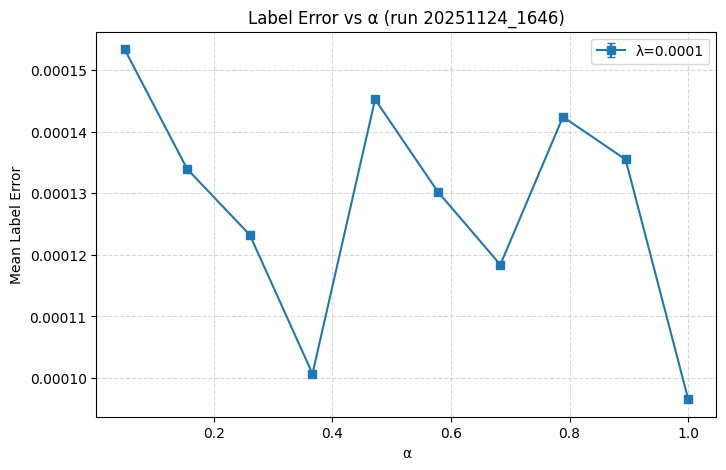

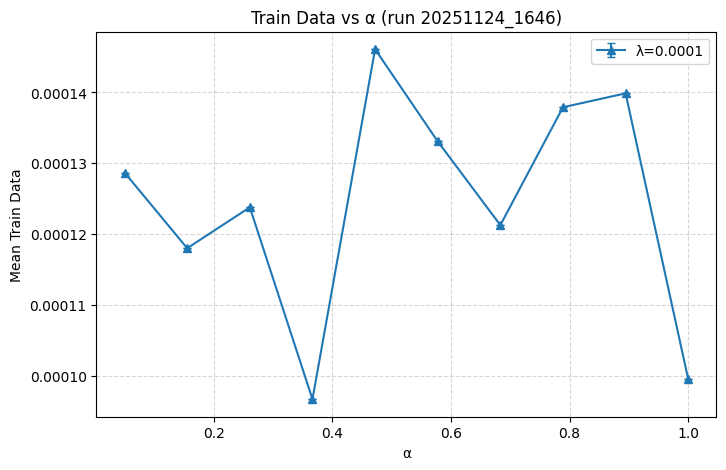

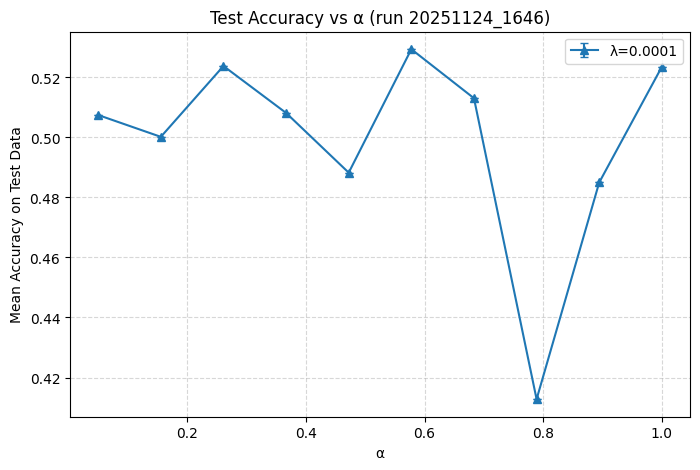

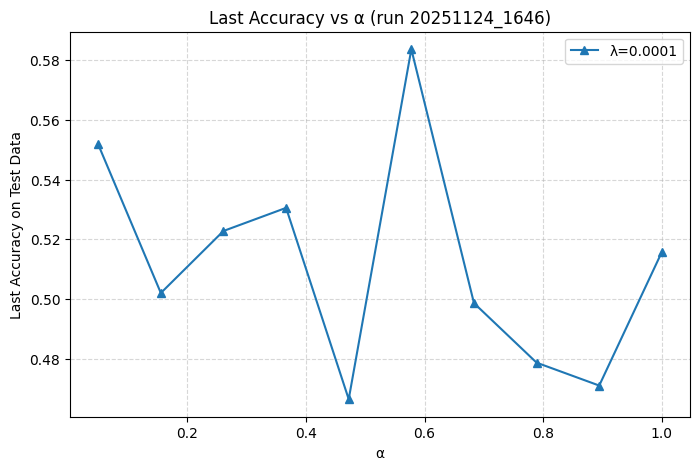

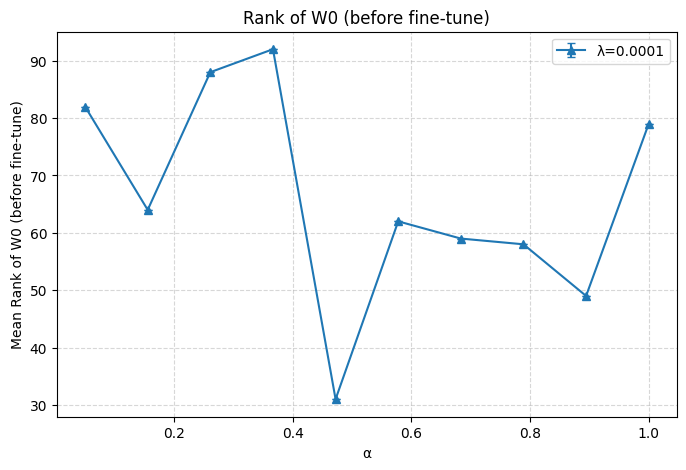

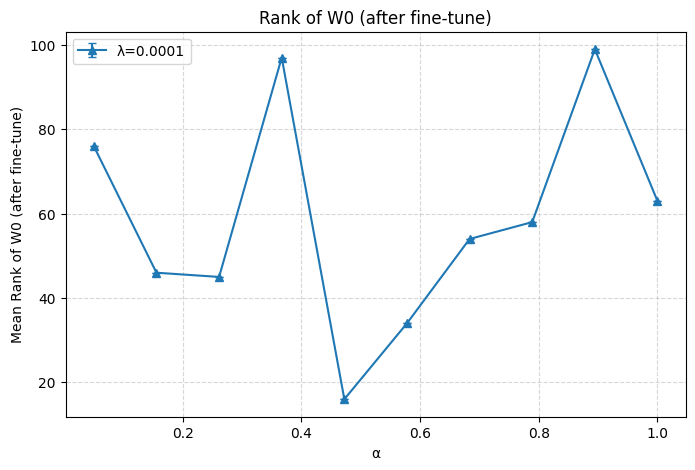

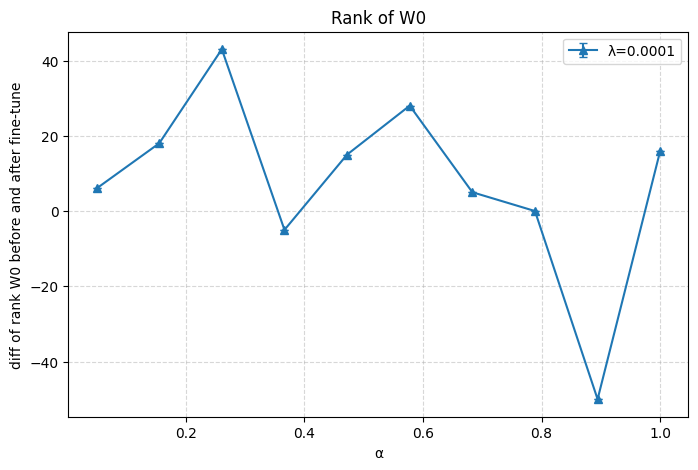

In [27]:
# --- Read the CSV file ---
df = pd.read_csv(base_path)
print(f"✅ Summary loaded ({len(df)} rows) from {base_path}")

# --- Quick preview ---
display(df.head())

# --- Plot Label Error vs alpha with error bars (grouped by lambda) ---
plt.figure(figsize=(8, 5))
for lam in sorted(df["lam"].unique()):
    subset = df[df["lam"] == lam].sort_values("alpha")
    plt.errorbar(subset["alpha"], subset["label_err_mean"], yerr=subset.get("label_err_std", 0),
                 marker='s', capsize=3, label=f"λ={lam}")
plt.xlabel("α")
plt.ylabel("Mean Label Error")
plt.title(f"Label Error vs α (run {run_id})")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

# --- Plot Train Data vs alpha with error bars (grouped by lambda) ---
plt.figure(figsize=(8, 5))
for lam in sorted(df["lam"].unique()):
    subset = df[df["lam"] == lam].sort_values("alpha")
    plt.errorbar(subset["alpha"], subset["train_data_mean"], yerr=subset.get("train_data_std", 0),
                 marker='^', capsize=3, label=f"λ={lam}")
plt.xlabel("α")
plt.ylabel("Mean Train Data")
plt.title(f"Train Data vs α (run {run_id})")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

# --- Plot Train Data vs alpha with error bars (grouped by lambda) ---
plt.figure(figsize=(8, 5))
for lam in sorted(df["lam"].unique()):
    subset = df[df["lam"] == lam].sort_values("alpha")
    plt.errorbar(subset["alpha"], subset["acc_test_mean"], yerr=subset.get("acc_test_std", 0),
                 marker='^', capsize=3, label=f"λ={lam}")
plt.xlabel("α")
plt.ylabel("Mean Accuracy on Test Data")
plt.title(f"Test Accuracy vs α (run {run_id})")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

# --- Plot Train Data vs alpha with error bars (grouped by lambda) ---
plt.figure(figsize=(8, 5))
for lam in sorted(df["lam"].unique()):
    subset = df[df["lam"] == lam].sort_values("alpha")
    plt.plot(subset["alpha"], subset["acc_train_last"], marker='^', label=f"λ={lam}")
plt.xlabel("α")
plt.ylabel("Last Accuracy on Test Data")
plt.title(f"Last Accuracy vs α (run {run_id})")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

# --- rank before fine tune---
plt.figure(figsize=(8, 5))
for lam in sorted(df["lam"].unique()):
    subset = df[df["lam"] == lam].sort_values("alpha")
    plt.errorbar(subset["alpha"], subset["rank_before_mean"], yerr=subset.get("rank_before_std", 0),
                 marker='^', capsize=3, label=f"λ={lam}")
plt.xlabel("α")
plt.ylabel("Mean Rank of W0 (before fine-tune)")
plt.title("Rank of W0 (before fine-tune)")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

# --- rank after fine tune ---
plt.figure(figsize=(8, 5))
for lam in sorted(df["lam"].unique()):
    subset = df[df["lam"] == lam].sort_values("alpha")
    plt.errorbar(subset["alpha"], subset["rank_after_mean"], yerr=subset.get("rank_after_std", 0),
                 marker='^', capsize=3, label=f"λ={lam}")
plt.xlabel("α")
plt.ylabel("Mean Rank of W0 (after fine-tune)")
plt.title("Rank of W0 (after fine-tune)")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

# --- diff rank ---
plt.figure(figsize=(8, 5))
for lam in sorted(df["lam"].unique()):
    subset = df[df["lam"] == lam].sort_values("alpha")
    plt.errorbar(subset["alpha"],  subset["rank_before_mean"]-subset["rank_after_mean"], yerr= subset.get("rank_before_std", 0)+subset.get("rank_after_std", 0),
                 marker='^', capsize=3, label=f"λ={lam}")
plt.xlabel("α")
plt.ylabel("diff of rank W0 before and after fine-tune")
plt.title("Rank of W0")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

## 3. Results visualisation

Found 10 heavy_data files.

--- File: ../results/run_20251124_1646/heavy_data_0.pkl ---
W_runs: type=list, length=1
  first element shape: (100, 100), dtype=float32
attn_matrices: type=list, length=1
  first element shape: (2000, 15, 15), dtype=float32
seq_samples: type=list, length=1
  first element shape: (2000, 15), dtype=int64
y_samples: type=list, length=1
  first element shape: (2000, 15), dtype=float32
acc_train: type=list, length=1
  first element type: <class 'list'>




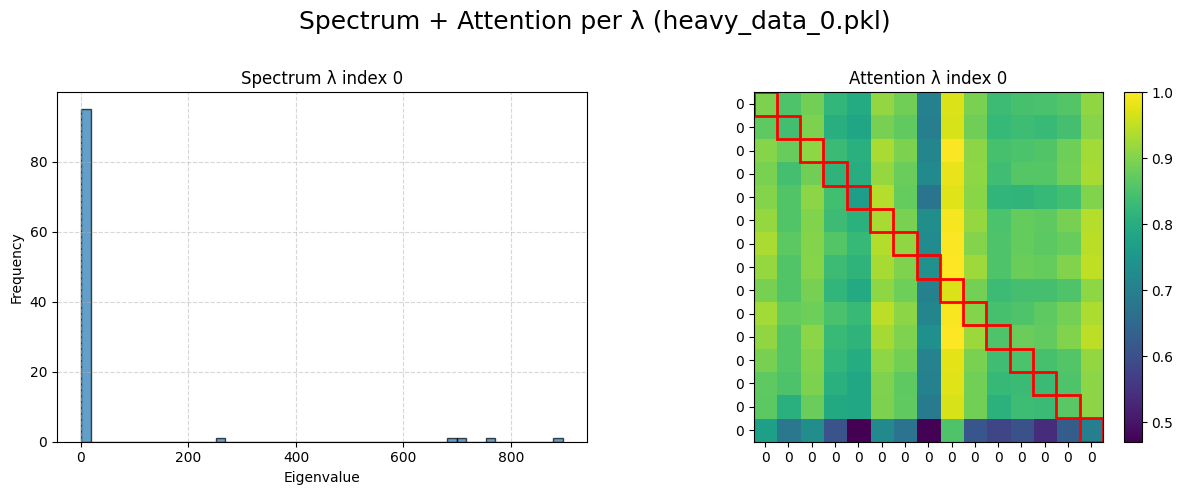

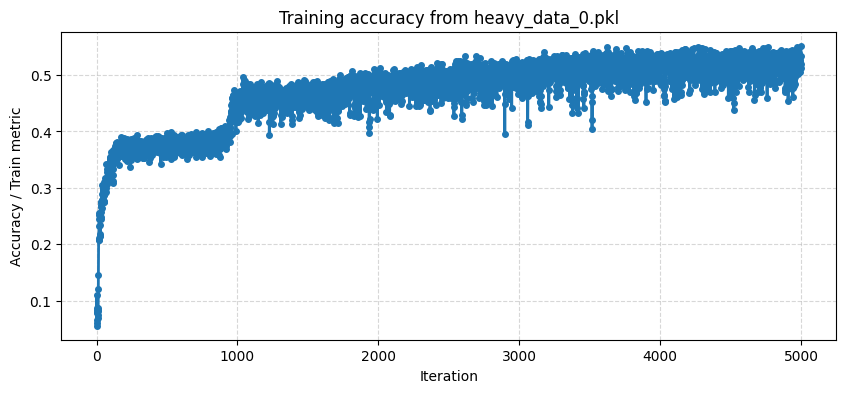

--- File: ../results/run_20251124_1646/heavy_data_1.pkl ---
W_runs: type=list, length=1
  first element shape: (100, 100), dtype=float32
attn_matrices: type=list, length=1
  first element shape: (2000, 15, 15), dtype=float32
seq_samples: type=list, length=1
  first element shape: (2000, 15), dtype=int64
y_samples: type=list, length=1
  first element shape: (2000, 15), dtype=float32
acc_train: type=list, length=1
  first element type: <class 'list'>




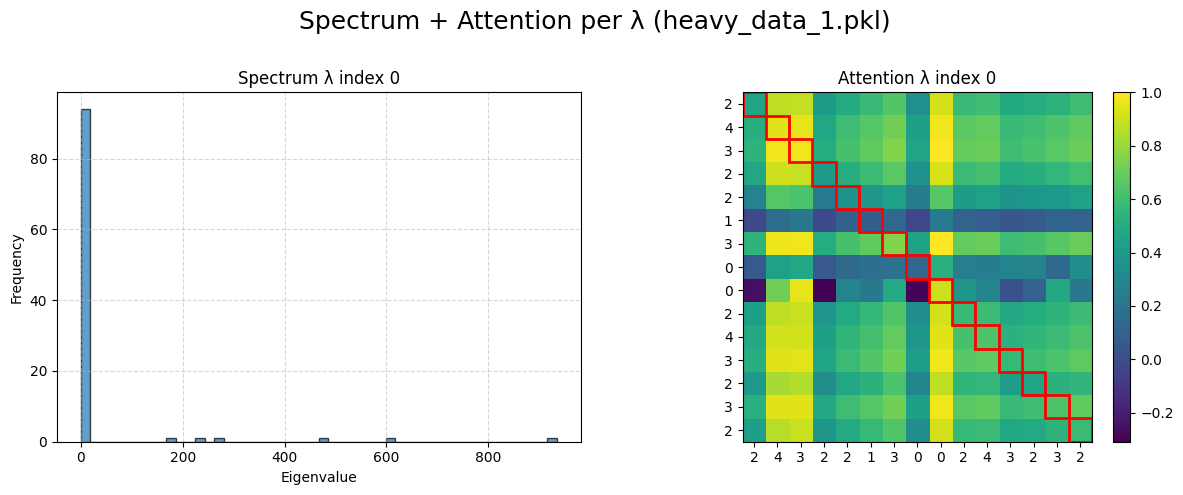

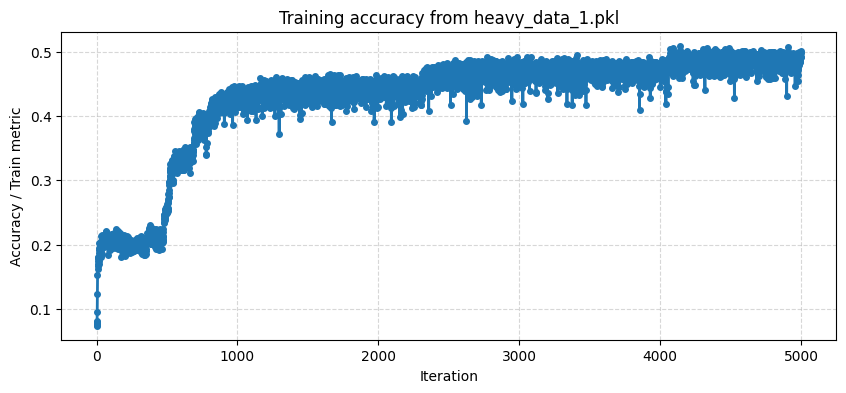

--- File: ../results/run_20251124_1646/heavy_data_2.pkl ---
W_runs: type=list, length=1
  first element shape: (100, 100), dtype=float32
attn_matrices: type=list, length=1
  first element shape: (2000, 15, 15), dtype=float32
seq_samples: type=list, length=1
  first element shape: (2000, 15), dtype=int64
y_samples: type=list, length=1
  first element shape: (2000, 15), dtype=float32
acc_train: type=list, length=1
  first element type: <class 'list'>




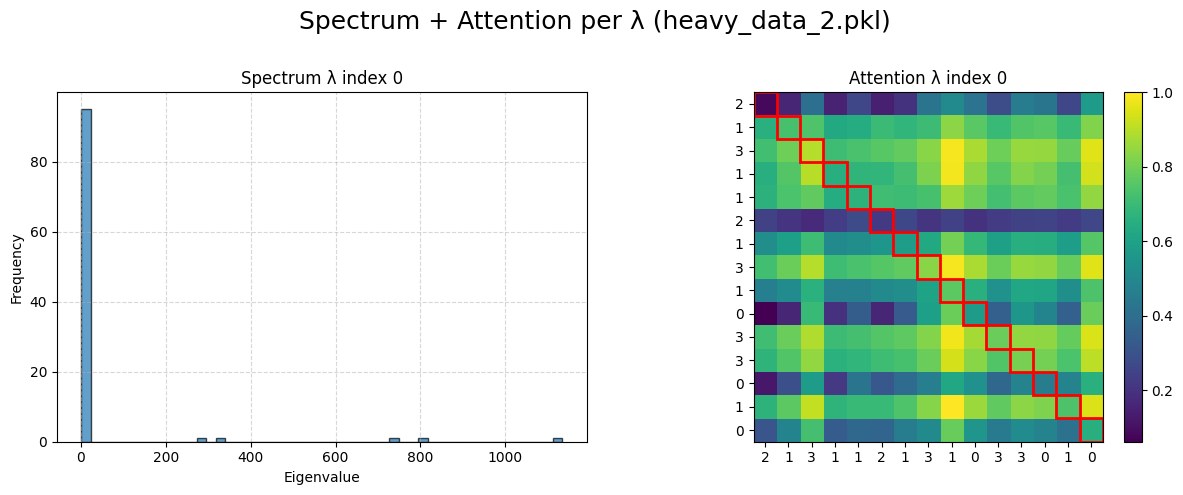

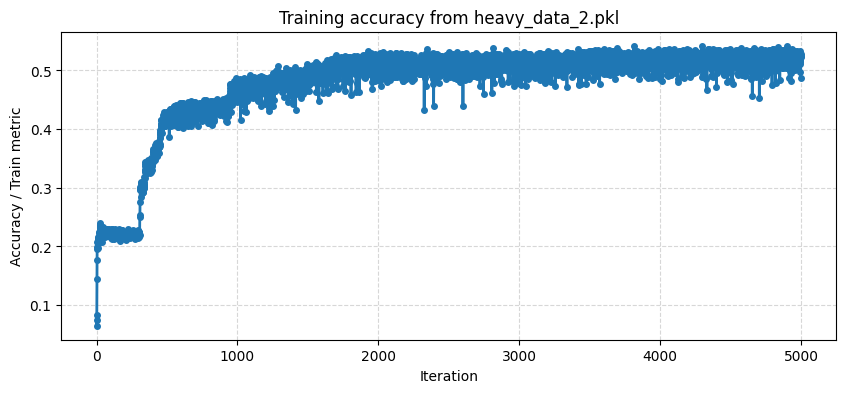

--- File: ../results/run_20251124_1646/heavy_data_3.pkl ---
W_runs: type=list, length=1
  first element shape: (100, 100), dtype=float32
attn_matrices: type=list, length=1
  first element shape: (2000, 15, 15), dtype=float32
seq_samples: type=list, length=1
  first element shape: (2000, 15), dtype=int64
y_samples: type=list, length=1
  first element shape: (2000, 15), dtype=float32
acc_train: type=list, length=1
  first element type: <class 'list'>




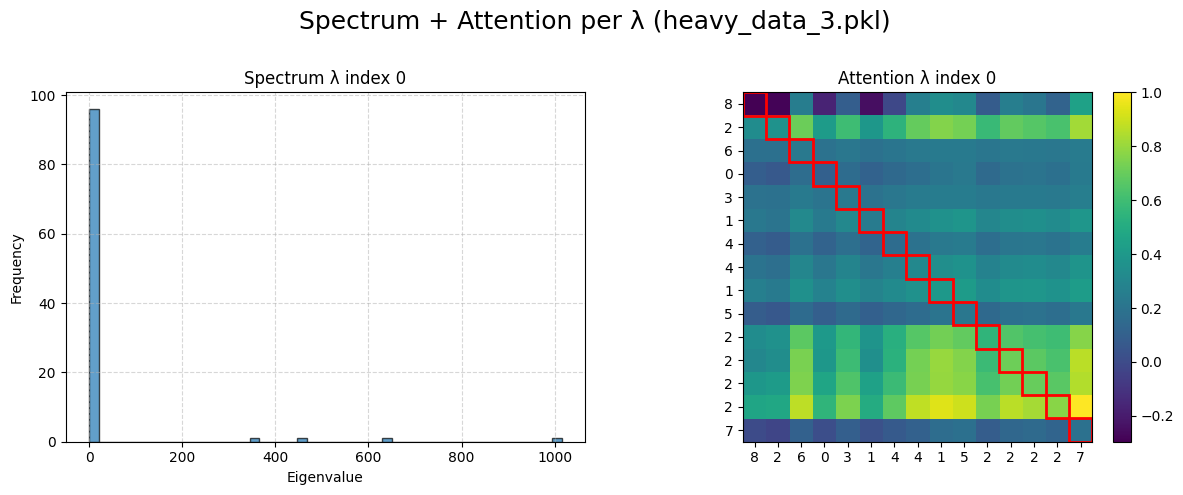

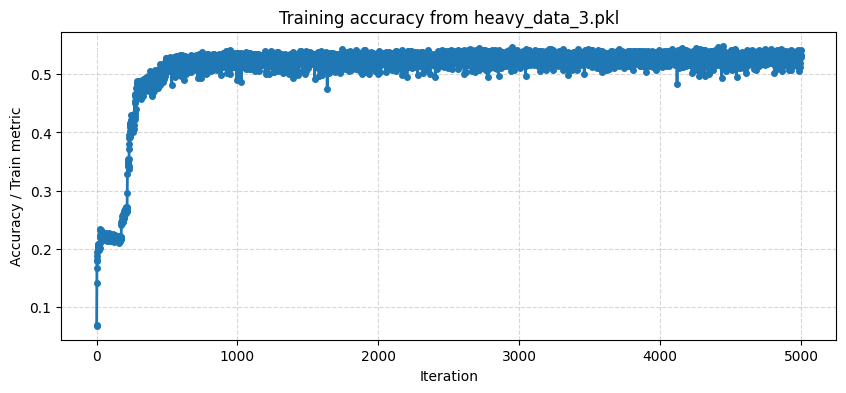

--- File: ../results/run_20251124_1646/heavy_data_4.pkl ---
W_runs: type=list, length=1
  first element shape: (100, 100), dtype=float32
attn_matrices: type=list, length=1
  first element shape: (2000, 15, 15), dtype=float32
seq_samples: type=list, length=1
  first element shape: (2000, 15), dtype=int64
y_samples: type=list, length=1
  first element shape: (2000, 15), dtype=float32
acc_train: type=list, length=1
  first element type: <class 'list'>




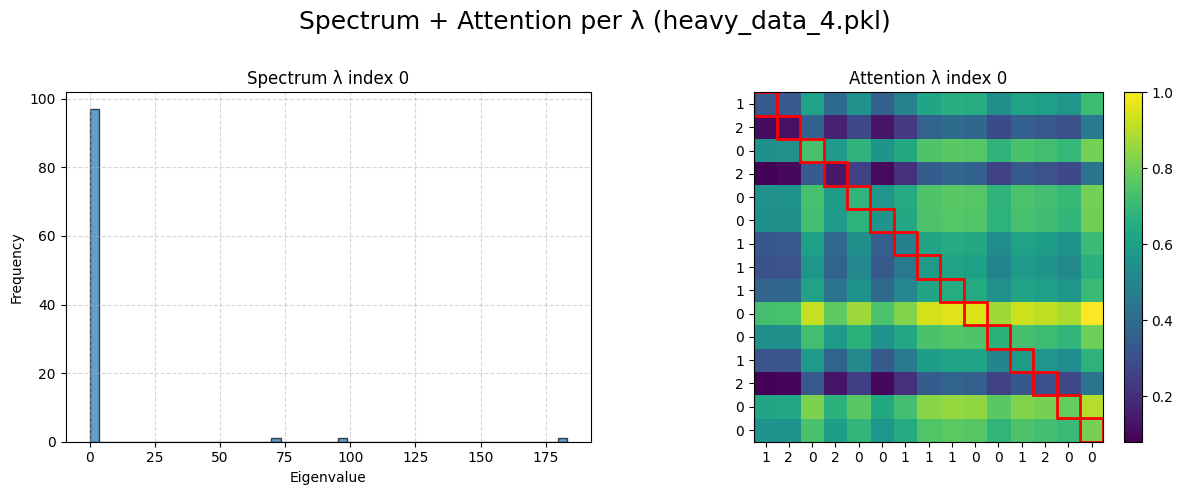

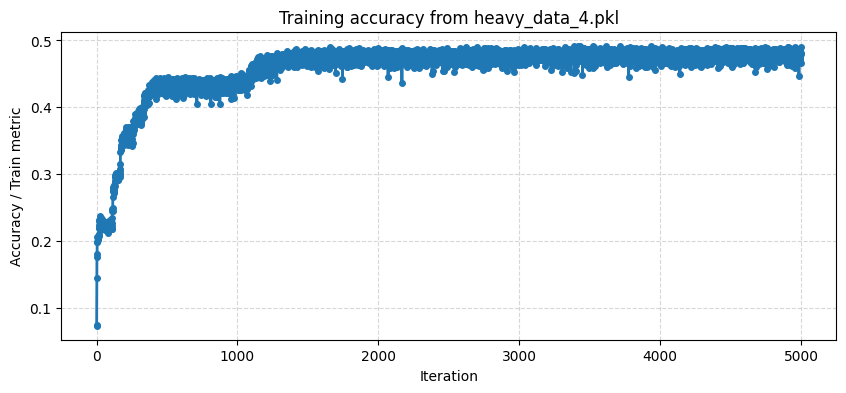

--- File: ../results/run_20251124_1646/heavy_data_5.pkl ---
W_runs: type=list, length=1
  first element shape: (100, 100), dtype=float32
attn_matrices: type=list, length=1
  first element shape: (2000, 15, 15), dtype=float32
seq_samples: type=list, length=1
  first element shape: (2000, 15), dtype=int64
y_samples: type=list, length=1
  first element shape: (2000, 15), dtype=float32
acc_train: type=list, length=1
  first element type: <class 'list'>




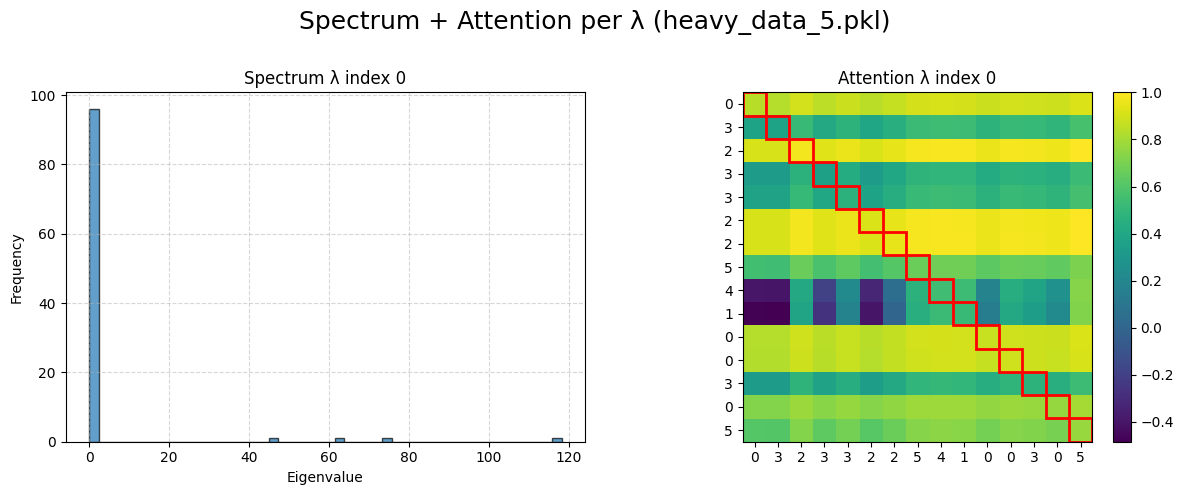

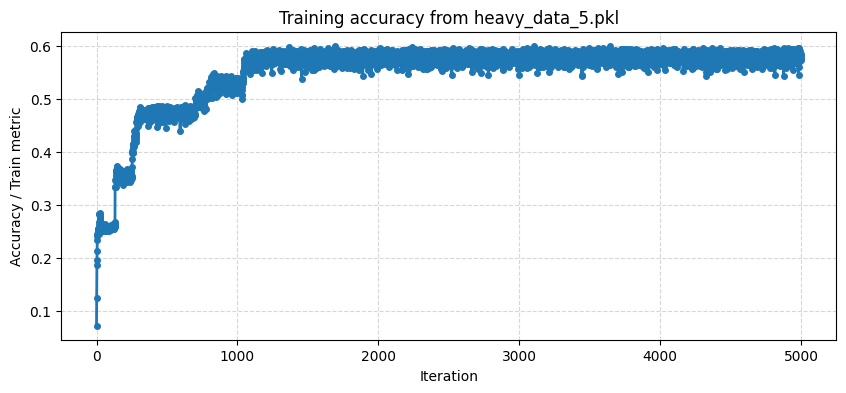

--- File: ../results/run_20251124_1646/heavy_data_6.pkl ---
W_runs: type=list, length=1
  first element shape: (100, 100), dtype=float32
attn_matrices: type=list, length=1
  first element shape: (2000, 15, 15), dtype=float32
seq_samples: type=list, length=1
  first element shape: (2000, 15), dtype=int64
y_samples: type=list, length=1
  first element shape: (2000, 15), dtype=float32
acc_train: type=list, length=1
  first element type: <class 'list'>




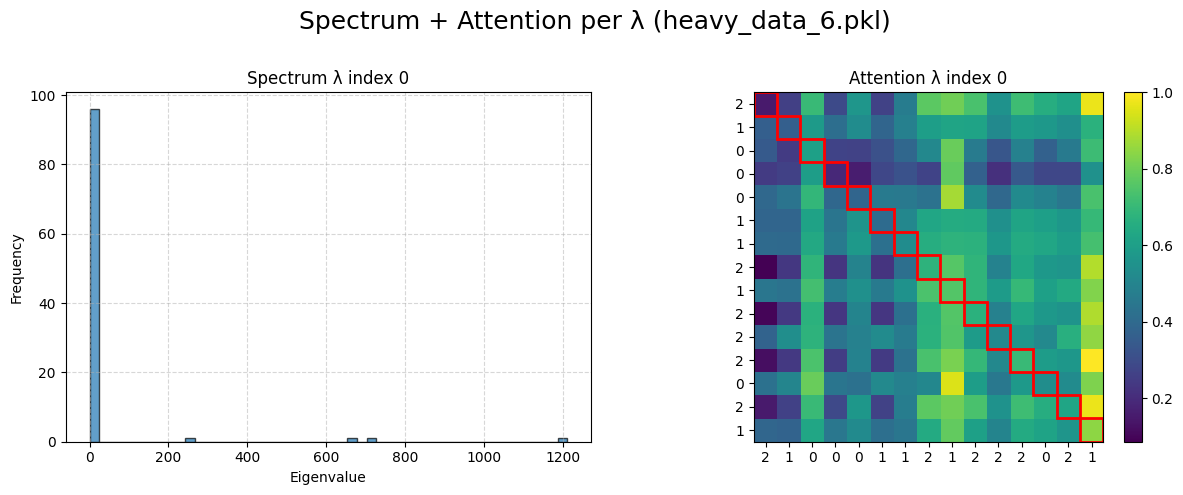

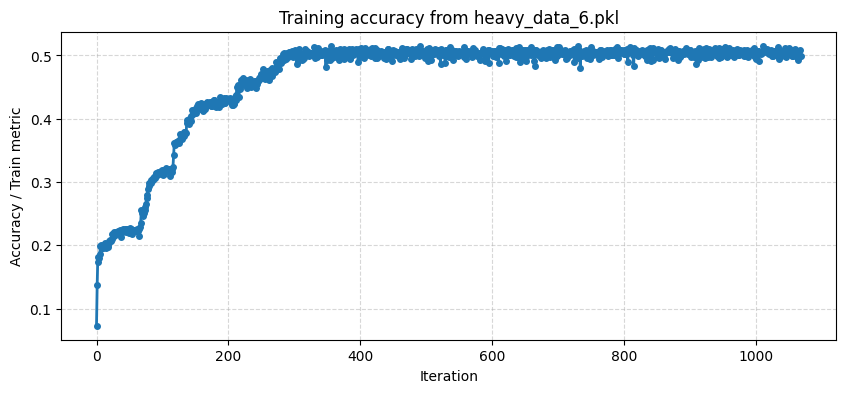

--- File: ../results/run_20251124_1646/heavy_data_7.pkl ---
W_runs: type=list, length=1
  first element shape: (100, 100), dtype=float32
attn_matrices: type=list, length=1
  first element shape: (2000, 15, 15), dtype=float32
seq_samples: type=list, length=1
  first element shape: (2000, 15), dtype=int64
y_samples: type=list, length=1
  first element shape: (2000, 15), dtype=float32
acc_train: type=list, length=1
  first element type: <class 'list'>




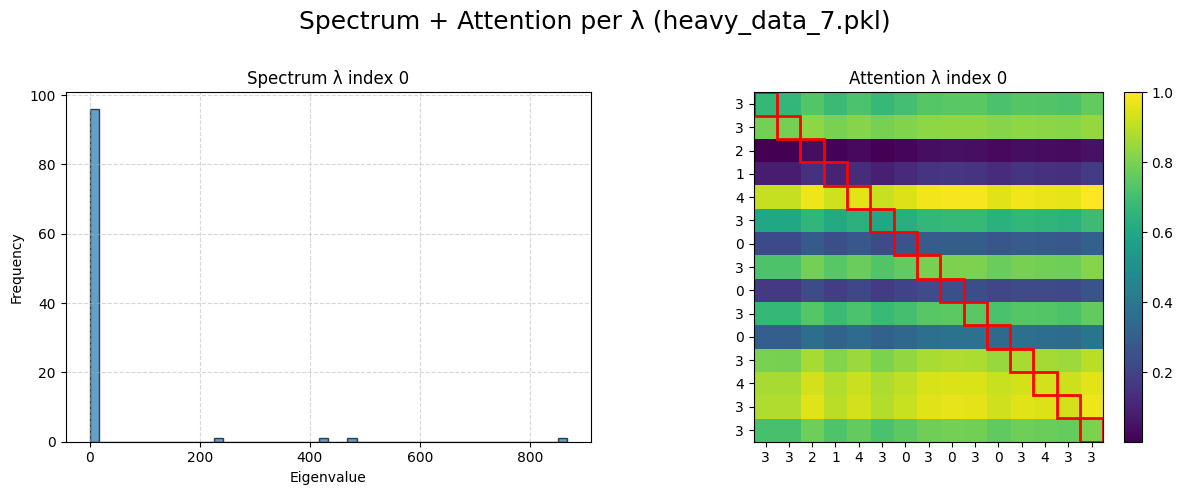

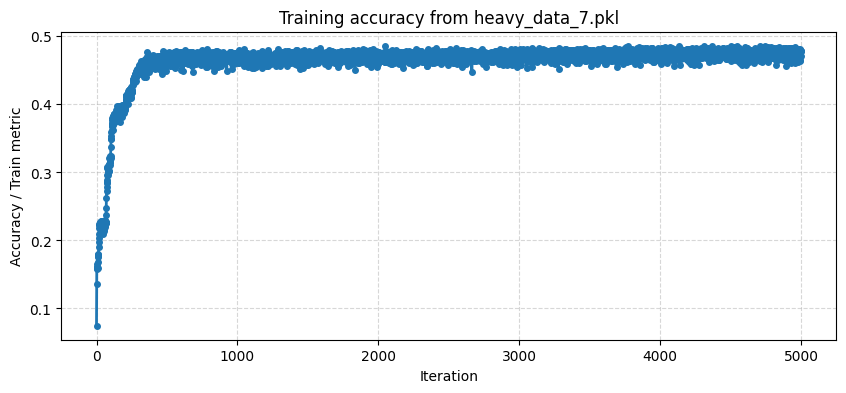

--- File: ../results/run_20251124_1646/heavy_data_8.pkl ---
W_runs: type=list, length=1
  first element shape: (100, 100), dtype=float32
attn_matrices: type=list, length=1
  first element shape: (2000, 15, 15), dtype=float32
seq_samples: type=list, length=1
  first element shape: (2000, 15), dtype=int64
y_samples: type=list, length=1
  first element shape: (2000, 15), dtype=float32
acc_train: type=list, length=1
  first element type: <class 'list'>




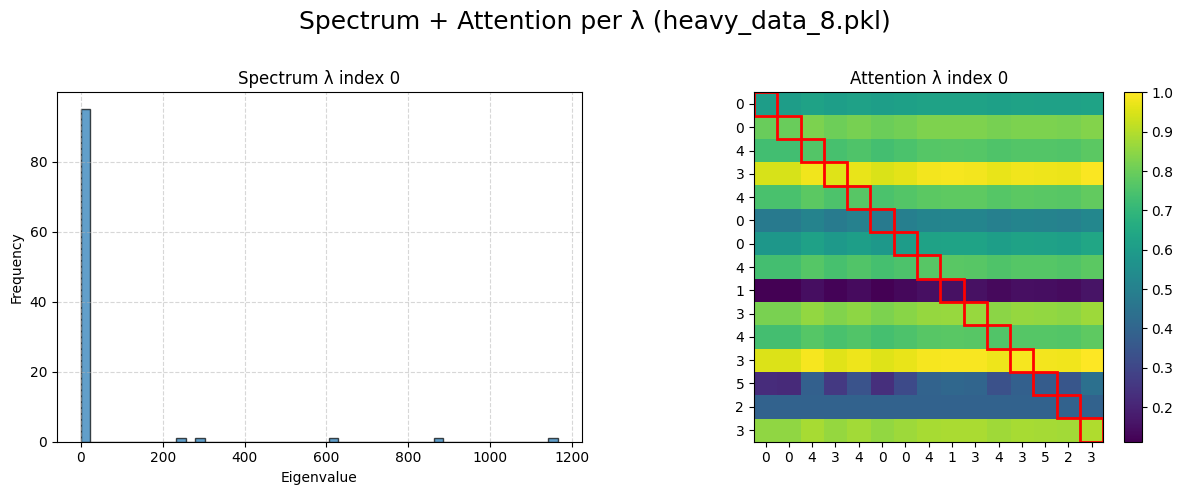

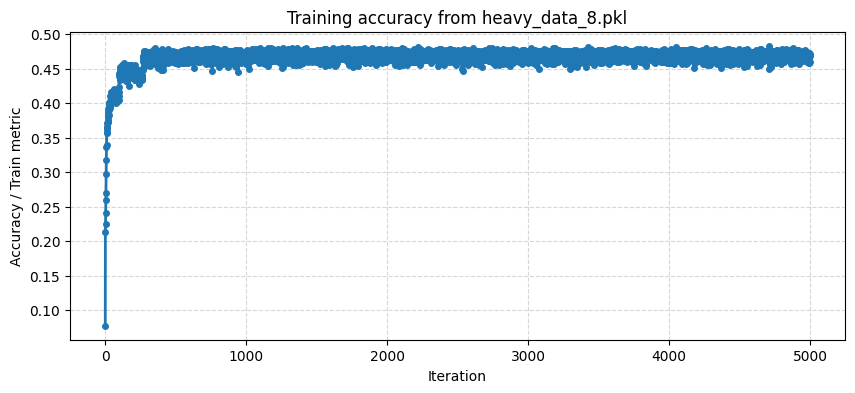

--- File: ../results/run_20251124_1646/heavy_data_9.pkl ---
W_runs: type=list, length=1
  first element shape: (100, 100), dtype=float32
attn_matrices: type=list, length=1
  first element shape: (2000, 15, 15), dtype=float32
seq_samples: type=list, length=1
  first element shape: (2000, 15), dtype=int64
y_samples: type=list, length=1
  first element shape: (2000, 15), dtype=float32
acc_train: type=list, length=1
  first element type: <class 'list'>




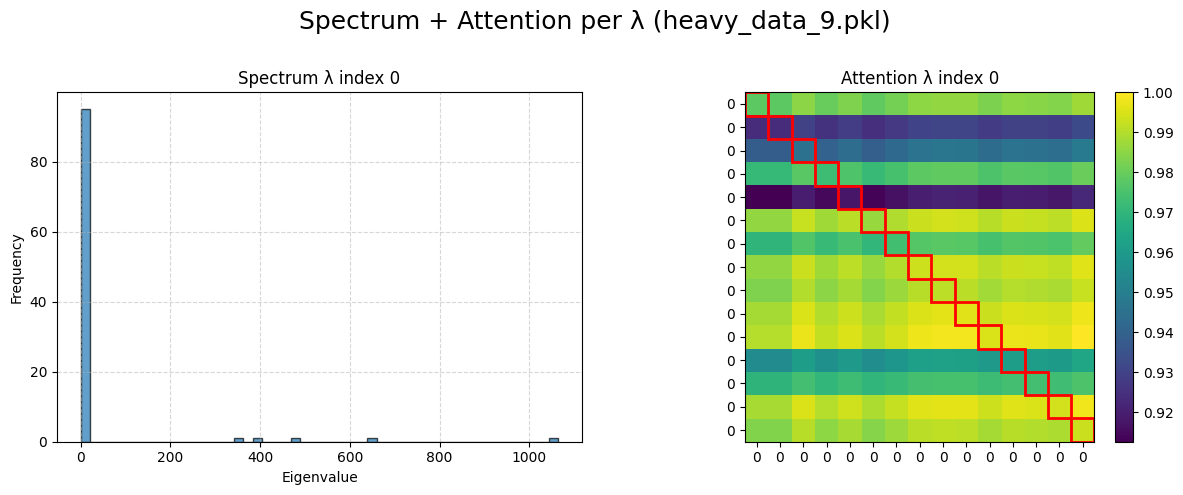

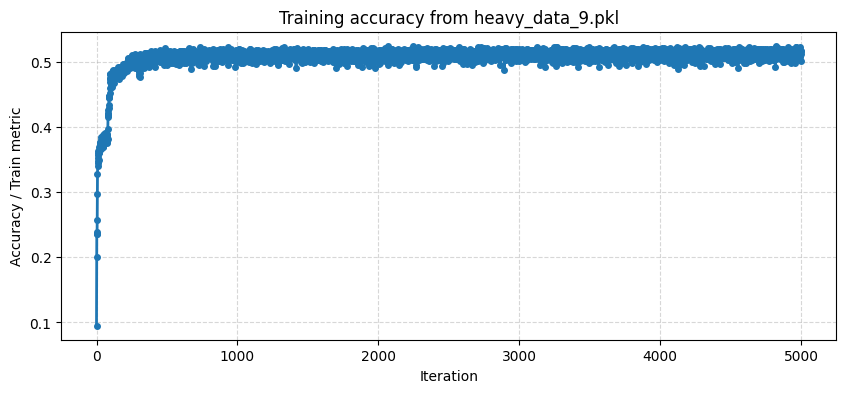

In [28]:
def highlight_diagonal(ax, seq_len, color='red', lw=2):
    """Draw rectangles along the diagonal of a matrix plot"""
    for i in range(seq_len):
        rect = plt.Rectangle((i-0.5, i-0.5), 1, 1, fill=False, color=color, lw=lw)
        ax.add_patch(rect)

def plot_heavy_data_with_metrics(run_dir, max_plots=5, overlay_y_samples=True, show_shapes=True):
    """
    Plot eigenvalue spectra, attention matrices, sequence samples, and acc_train from the heavy_data pickle.
    Only plots up to max_plots λ values per run.
    overlay_y_samples: if True, plots y_samples overlay on attention matrices.
    show_shapes: if True, prints all keys with type/shape info.
    """
    heavy_files = sorted(glob.glob(os.path.join(run_dir, "heavy_data_*.pkl")))
    print(f"Found {len(heavy_files)} heavy_data files.\n")

    for heavy_file in heavy_files:
        print(f"--- File: {heavy_file} ---")
        with open(heavy_file, "rb") as f:
            data = pickle.load(f)
        
        if show_shapes:
            # Afficher toutes les clés et shape/type
            for key, val in data.items():
                if isinstance(val, np.ndarray):
                    print(f"{key}: type={type(val)}, shape={val.shape}, dtype={val.dtype}")
                elif isinstance(val, torch.Tensor):
                    print(f"{key}: type={type(val)}, shape={val.shape}, dtype={val.dtype}")
                elif isinstance(val, list):
                    print(f"{key}: type=list, length={len(val)}")
                    if len(val) > 0:
                        first = val[0]
                        if isinstance(first, np.ndarray):
                            print(f"  first element shape: {first.shape}, dtype={first.dtype}")
                        elif isinstance(first, torch.Tensor):
                            print(f"  first element shape: {first.shape}, dtype={first.dtype}")
                        else:
                            print(f"  first element type: {type(first)}")
                else:
                    print(f"{key}: type={type(val)}")
            print("\n")

        W_runs_all = data.get("W_runs", [])
        attn_matrices = data.get("attn_matrices", [])
        seq_samples = data.get("seq_samples", [])
        y_samples = data.get("y_samples", None)
        acc_train = data.get("acc_train", None)

        # --- Plots Eigenvalue & Attention ---
        n_plots = min(len(W_runs_all), len(attn_matrices), max_plots)
        fig, axes = plt.subplots(n_plots, 2, figsize=(12, 5 * n_plots))
        if n_plots == 1:
            axes = axes.reshape(1, 2)

        for i in range(n_plots):
            # Left: Eigenvalue spectrum
            W_matrix = W_runs_all[i]
            eigvals_all = np.linalg.eigvalsh(W_matrix @ W_matrix.T)
            ax_left = axes[i, 0]
            ax_left.hist(eigvals_all, bins=50, alpha=0.7, edgecolor='black')
            ax_left.set_title(f"Spectrum λ index {i}")
            ax_left.set_xlabel("Eigenvalue")
            ax_left.set_ylabel("Frequency")
            ax_left.grid(True, linestyle="--", alpha=0.5)

            # Right: Attention matrix
            attn_matrix = attn_matrices[i]
            if isinstance(attn_matrix, torch.Tensor):
                attn_matrix = attn_matrix.cpu().numpy()
            if attn_matrix.ndim == 3:
                attn_matrix = attn_matrix[-1]

            if np.max(attn_matrix) != 0:
                attn_matrix = attn_matrix / np.max(attn_matrix)

            seq_vals = np.array(seq_samples[i])
            if seq_vals.ndim == 2:
                seq_vals = seq_vals[-1]
            seq_vals = [str(int(s)) if np.issubdtype(type(s), np.number) else str(s) for s in seq_vals]

            ax_right = axes[i, 1]
            im = ax_right.imshow(attn_matrix, cmap='viridis')
            highlight_diagonal(ax_right, len(seq_vals))
            ax_right.set_xticks(np.arange(len(seq_vals)))
            ax_right.set_yticks(np.arange(len(seq_vals)))
            ax_right.set_xticklabels(seq_vals)
            ax_right.set_yticklabels(seq_vals)
            ax_right.set_title(f"Attention λ index {i}")
            fig.colorbar(im, ax=ax_right, fraction=0.046, pad=0.04)

            #if overlay_y_samples and y_samples is not None:
             #   y_vals = np.array(y_samples[i])
            #    if y_vals.ndim == 2:
            #        y_vals = y_vals[-1]
             #   ax_right.plot(np.arange(len(y_vals)), y_vals, 'r--', marker='x', label='y sample')
            #    ax_right.legend()

        fig.suptitle(f"Spectrum + Attention per λ ({os.path.basename(heavy_file)})", fontsize=18)
        plt.tight_layout(rect=[0, 0, 1, 0.97])
        plt.show()

        # --- Plot acc_train ---
        if len(acc_train) > 0:
            acc_vals = acc_train[0]
            if isinstance(acc_vals, list):
                acc_vals = np.array(acc_vals)
            plt.figure(figsize=(10,4))
            plt.plot(acc_vals, 'o-', lw=2, markersize=4, label='Train Accuracy')
            plt.xlabel("Iteration")
            plt.ylabel("Accuracy / Train metric")
            plt.title(f"Training accuracy from {os.path.basename(heavy_file)}")
            plt.grid(True, linestyle="--", alpha=0.5)
            plt.show()

# --- Usage ---
plot_heavy_data_with_metrics(run_dir, max_plots=100, overlay_y_samples=True, show_shapes=True)

Found 10 pickle files.


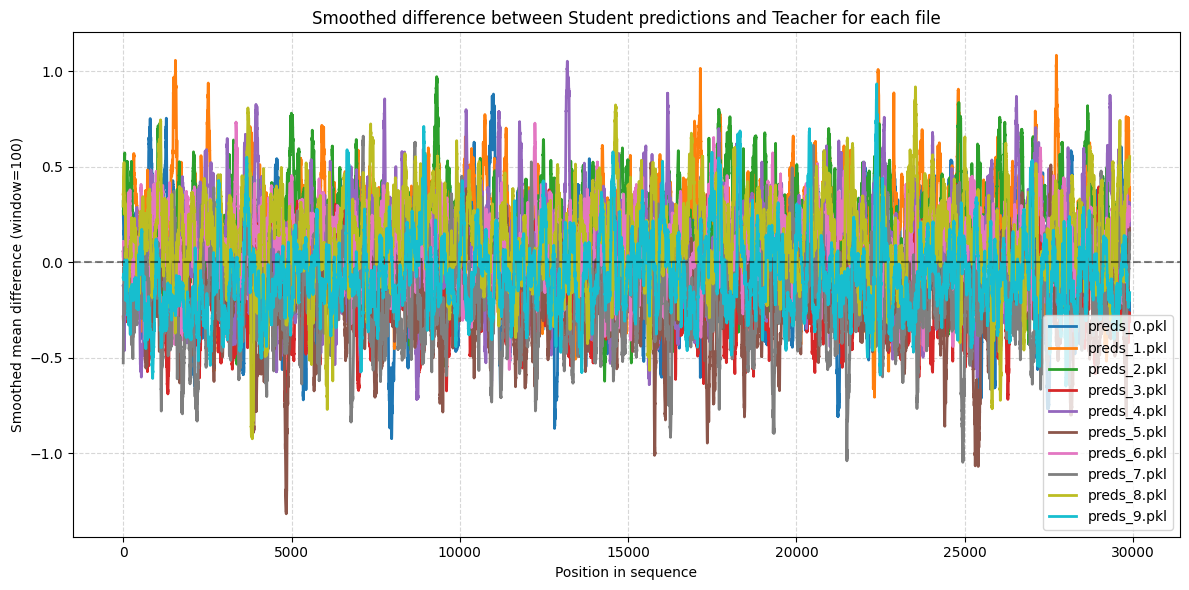

In [29]:
# --- Liste de tous les fichiers pickle ---
preds_pickle_files = sorted(glob.glob(os.path.join(run_dir, "preds_*.pkl")))
print(f"Found {len(preds_pickle_files)} pickle files.")

window_size = 100  # taille de la fenêtre de la moyenne glissante

plt.figure(figsize=(12, 6))

for path in preds_pickle_files:
    # --- Load pickle ---
    with open(path, "rb") as f:
        data = pickle.load(f)
    
    student_preds = data["student_pred_samples"]
    teacher_truth = data["teacher_true_samples"]
    
    # Flatten sequences
    student_preds_flat = [np.array(s).flatten() for s in student_preds]
    teacher_truth_flat = [np.array(t).flatten() for t in teacher_truth]
    
    # Compute difference for each sequence
    diffs = [s - t for s, t in zip(student_preds_flat, teacher_truth_flat)]
    
    # Compute mean difference across sequences in this file
    mean_diff = np.mean(np.stack(diffs), axis=0)
    
    # --- Apply moving average / rolling mean ---
    smoothed_diff = np.convolve(mean_diff, np.ones(window_size)/window_size, mode='valid')
    
    # Plot smoothed mean difference
    plt.plot(smoothed_diff, lw=2, label=os.path.basename(path))

plt.axhline(0, color='k', linestyle='--', alpha=0.5)  # zero line
plt.xlabel("Position in sequence")
plt.ylabel(f"Smoothed mean difference (window={window_size})")
plt.title("Smoothed difference between Student predictions and Teacher for each file")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()